# Retail CMBS Credit Risk Modeling
**Author:** Ruoling (Iris) Li 
**Description:** End-to-end ML pipeline predicting Debt Service Coverage Ratio (DSCR) and at-risk status for California retail commercial mortgage-backed securities using Trepp loan-level data.  

# Retail CMBS Risk Analysis — V5: Income-Side Features

**Dataset:** Trepp CMBS — California retail properties (df_model_small.csv)  
**Target:** Predict DSCR (regression) and at-risk status DSCR < 1.2 (classification)  
**Key improvement:** Revenue, expense, NOI, and margin data now available  

### Methodology

| Safeguard | Implementation |
|-----------|---------------|
| Data leakage | Exclude ncf_psf (DSCR numerator), secPropBal & bal_psf (DSCR denominator) |
| Property overlap | Strict 3-way split: 0% overlap between train, val, test |
| Encoder leakage | Fit on train only; unseen categories → 'Unknown' |
| Categorical encoding | OHE for linear models; LabelEncoder for trees |
| Class imbalance | class_weight='balanced' + PR-AUC metric |
| Threshold tuning | Max-F1 and Recall@Precision≥0.15 on val; apply to test |

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              RandomForestClassifier, GradientBoostingClassifier)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                             accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, average_precision_score,
                             precision_recall_curve, confusion_matrix, classification_report)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('data/df_model_small.csv', low_memory=False)  # place data file in data/
print(f'Raw: {len(df):,} rows, {df["masterpropidtrepp"].nunique():,} properties, {len(df.columns)} columns')

Raw: 105,338 rows, 4,141 properties, 35 columns


## 2. Feature Engineering

In [2]:
df['at_risk'] = (df['securdscr'] < 1.2).astype(float)

# === ENGINEERED FEATURES ===

# Revenue yield on debt: how much top-line revenue covers per dollar of debt
df['revenue_to_bal'] = df['revenue_psf'] / (df['bal_psf'] + 1e-6)

# Effective income rate: occupancy × NOI margin (combines vacancy + cost efficiency)
df['effective_noi_rate'] = df['occ_base'] * df['noi_margin']

# Concentration × rollover risk interaction
df['conc_x_rollover'] = df['hhi_top3'] * df['pct_exp_12m_top3']

# Debt yield proxy: NOI per sqft / balance per sqft ≈ NOI / Loan Balance
df['debt_yield_proxy'] = df['noi_psf'] / (df['bal_psf'] + 1e-6)

# Log of sqft (highly skewed distribution)
df['log_sqft'] = np.log1p(df['sqft_base'])

print('Engineered 5 features: revenue_to_bal, effective_noi_rate, conc_x_rollover, '
      'debt_yield_proxy, log_sqft')

Engineered 5 features: revenue_to_bal, effective_noi_rate, conc_x_rollover, debt_yield_proxy, log_sqft


## 3. Leakage Audit & Feature Selection

In [3]:
# DSCR = Net Cash Flow / Debt Service
# Debt Service = f(Loan Balance, Rate, Term)

audit = {
    # KEEP — Loan metrics (not cash flow)
    'secLTV':           ('✅ KEEP',    'Loan-to-Value ratio — equity cushion'),
    'allocbalpct':      ('✅ KEEP',    'Allocation balance % — loan structure'),
    'high_ltv_flag':    ('✅ KEEP',    'High LTV indicator'),
    'ltv_x_roll12':     ('✅ KEEP',    'LTV × 12-month rollover interaction'),
    # KEEP — Property characteristics
    'sqft_base':        ('✅ KEEP',    'Rentable square footage'),
    'log_sqft':         ('✅ KEEP',    'Log(sqft) — handles skew'),
    'occ_base':         ('✅ KEEP',    'Occupancy rate'),
    'low_occ_flag':     ('✅ KEEP',    'Low occupancy indicator'),
    # KEEP — Income side (THE NEW DATA)
    'revenue_psf':      ('✅ KEEP',    'Revenue per sqft — top-line income'),
    'expense_psf':      ('✅ KEEP',    'Expense per sqft — cost structure'),
    'noi_psf':          ('✅ KEEP',    'NOI per sqft — operating income (not identical to DSCR)'),
    'expense_ratio':    ('✅ KEEP',    'Expense / Revenue — cost efficiency'),
    'noi_margin':       ('✅ KEEP',    'NOI / Revenue — operating margin'),
    'ncf_margin':       ('✅ KEEP',    'NCF / Revenue — cash flow margin'),
    # KEEP — Tenant/lease
    'top1_share':       ('✅ KEEP',    'Top tenant share — concentration'),
    'top3_share':       ('✅ KEEP',    'Top 3 tenant share'),
    'hhi_top3':         ('✅ KEEP',    'HHI concentration index'),
    'pct_exp_12m_top3': ('✅ KEEP',    'Top 3 lease expiry in 12 months'),
    'wault_top3_months':('✅ KEEP',    'Weighted average lease term — top 3'),
    # KEEP — Engineered
    'revenue_to_bal':   ('✅ ENG',     'Revenue PSF / Balance PSF — revenue yield on debt'),
    'effective_noi_rate':('✅ ENG',    'Occ × NOI margin — effective income rate'),
    'conc_x_rollover':  ('✅ ENG',     'HHI × 12m expiry — concentration-rollover risk'),
    'debt_yield_proxy': ('✅ ENG',     'NOI PSF / Balance PSF ≈ debt yield'),
    # KEEP — Location
    'lat':              ('✅ KEEP',    'Latitude'),
    'long':             ('✅ KEEP',    'Longitude'),
    # EXCLUDE — DSCR components
    'ncf_psf':          ('❌ EXCLUDE', 'NCF/sqft ≈ DSCR numerator/sqft — direct leakage'),
    'secPropBal':       ('❌ EXCLUDE', 'Loan balance → debt service (DSCR denominator)'),
    'bal_psf':          ('❌ EXCLUDE', 'Balance/sqft → same as above, normalized'),
}

df_ml = df[df['securdscr'].notna()].copy()
target = 'securdscr'

print(f'{"Feature":25s} {"Status":12s} {"r(DSCR)":>8s}  Reason')
print('—' * 90)
for feat, (status, reason) in audit.items():
    if feat in df_ml.columns:
        corr = df_ml[feat].corr(df_ml[target])
        print(f'{status[:1]} {feat:24s} {status[2:]:12s} r={corr:+.3f}  {reason}')

print(f'\n✅ Using: {sum(1 for v in audit.values() if "KEEP" in v[0] or "ENG" in v[0])} features')
print(f'❌ Excluded: ncf_psf, secPropBal, bal_psf (DSCR components)')

Feature                   Status        r(DSCR)  Reason
——————————————————————————————————————————————————————————————————————————————————————————
✅ secLTV                   KEEP         r=-0.715  Loan-to-Value ratio — equity cushion
✅ allocbalpct              KEEP         r=-0.410  Allocation balance % — loan structure
✅ high_ltv_flag            KEEP         r=+0.018  High LTV indicator
✅ ltv_x_roll12             KEEP         r=+0.047  LTV × 12-month rollover interaction
✅ sqft_base                KEEP         r=+0.216  Rentable square footage
✅ log_sqft                 KEEP         r=+0.221  Log(sqft) — handles skew
✅ occ_base                 KEEP         r=+0.099  Occupancy rate
✅ low_occ_flag             KEEP         r=-0.076  Low occupancy indicator
✅ revenue_psf              KEEP         r=-0.104  Revenue per sqft — top-line income
✅ expense_psf              KEEP         r=-0.171  Expense per sqft — cost structure
✅ noi_psf                  KEEP         r=-0.079  NOI per sqft — o

In [4]:
num_features = [
    'secLTV', 'allocbalpct', 'high_ltv_flag', 'ltv_x_roll12',
    'sqft_base', 'log_sqft', 'occ_base', 'low_occ_flag',
    'revenue_psf', 'expense_psf', 'noi_psf', 'expense_ratio', 'noi_margin', 'ncf_margin',
    'top1_share', 'top3_share', 'hhi_top3', 'pct_exp_12m_top3', 'wault_top3_months',
    'revenue_to_bal', 'effective_noi_rate', 'conc_x_rollover', 'debt_yield_proxy',
    'lat', 'long',
]
cat_features = ['msashort']

# Fill missing values
for f in num_features:
    if df_ml[f].isnull().any():
        n = df_ml[f].isnull().sum()
        df_ml[f] = df_ml[f].fillna(df_ml[f].median())
        print(f'  Filled {f}: {n:,} nulls → median')
for c in cat_features:
    df_ml[c] = df_ml[c].fillna('Unknown')

print(f'\nML dataset: {len(df_ml):,} rows, {df_ml["masterpropidtrepp"].nunique():,} properties')
print(f'At-risk rate: {df_ml["at_risk"].mean()*100:.2f}%')

  Filled secLTV: 45 nulls → median
  Filled ltv_x_roll12: 45 nulls → median
  Filled sqft_base: 26 nulls → median
  Filled log_sqft: 26 nulls → median
  Filled occ_base: 3,344 nulls → median
  Filled revenue_psf: 8,821 nulls → median
  Filled expense_psf: 9,386 nulls → median
  Filled noi_psf: 1,931 nulls → median
  Filled expense_ratio: 9,686 nulls → median
  Filled noi_margin: 8,821 nulls → median
  Filled ncf_margin: 8,821 nulls → median
  Filled top1_share: 2,786 nulls → median
  Filled wault_top3_months: 20,057 nulls → median
  Filled revenue_to_bal: 8,821 nulls → median
  Filled effective_noi_rate: 10,083 nulls → median
  Filled debt_yield_proxy: 1,931 nulls → median
  Filled lat: 164 nulls → median
  Filled long: 164 nulls → median

ML dataset: 54,129 rows, 2,052 properties
At-risk rate: 1.44%


## 4. Strict Property-Level Split

In [5]:
all_props = df_ml['masterpropidtrepp'].unique()
np.random.seed(42)
np.random.shuffle(all_props)

n = len(all_props)
train_props = set(all_props[:int(n * 0.6)])
val_props   = set(all_props[int(n * 0.6):int(n * 0.8)])
test_props  = set(all_props[int(n * 0.8):])

train_data = df_ml[df_ml['masterpropidtrepp'].isin(train_props)].copy()
val_data   = df_ml[df_ml['masterpropidtrepp'].isin(val_props)].copy()
test_data  = df_ml[df_ml['masterpropidtrepp'].isin(test_props)].copy()

assert len(train_props & val_props) == 0
assert len(train_props & test_props) == 0
assert len(val_props & test_props) == 0

print('=== Strict 3-Way Property Split ===')
print(f'Train: {len(train_data):>7,} rows | {len(train_props):,} props | At-risk: {train_data["at_risk"].mean()*100:.2f}%')
print(f'Val:   {len(val_data):>7,} rows | {len(val_props):,} props | At-risk: {val_data["at_risk"].mean()*100:.2f}%')
print(f'Test:  {len(test_data):>7,} rows | {len(test_props):,} props | At-risk: {test_data["at_risk"].mean()*100:.2f}%')
print(f'✅ Zero property overlap across all 3 sets')

=== Strict 3-Way Property Split ===
Train:  32,253 rows | 1,231 props | At-risk: 1.36%
Val:    10,834 rows | 410 props | At-risk: 1.50%
Test:   11,042 rows | 411 props | At-risk: 1.62%
✅ Zero property overlap across all 3 sets


## 5. Encoding (Fit on Train Only)

In [6]:
# LabelEncoder for trees
label_encoders = {}
for col in cat_features:
    le = LabelEncoder()
    cats = list(train_data[col].unique())
    if 'Unknown' not in cats: cats.append('Unknown')
    le.fit(cats); label_encoders[col] = le; known = set(le.classes_)
    for d in [train_data, val_data, test_data]:
        d[col + '_enc'] = d[col].apply(lambda x, k=known: x if x in k else 'Unknown')
        d[col + '_enc'] = le.transform(d[col + '_enc'])

# OneHotEncoder for linear models
ohe = OneHotEncoder(sparse_output=False, drop='first',
                    handle_unknown='infrequent_if_exist', min_frequency=0.01)
ohe.fit(train_data[cat_features])

# Build feature matrices
tree_feats = num_features + [c + '_enc' for c in cat_features]
tree_labels = [f.replace('_enc', '') for f in tree_feats]

X_train_tree, X_val_tree, X_test_tree = (
    d[tree_feats].values for d in [train_data, val_data, test_data])

X_train_lin = np.hstack([train_data[num_features].values, ohe.transform(train_data[cat_features])])
X_val_lin   = np.hstack([val_data[num_features].values, ohe.transform(val_data[cat_features])])
X_test_lin  = np.hstack([test_data[num_features].values, ohe.transform(test_data[cat_features])])

scaler = StandardScaler()
X_train_lin_sc = scaler.fit_transform(X_train_lin)
X_val_lin_sc   = scaler.transform(X_val_lin)
X_test_lin_sc  = scaler.transform(X_test_lin)

y_train, y_val, y_test = (d['securdscr'].values for d in [train_data, val_data, test_data])
y_train_cls, y_val_cls, y_test_cls = (
    d['at_risk'].values.astype(int) for d in [train_data, val_data, test_data])

print(f'Tree: {len(tree_feats)} features | Linear: {X_train_lin.shape[1]} features (OHE)')

Tree: 26 features | Linear: 39 features (OHE)


## 6. Regression

In [7]:
reg_models = [
    ('Linear Regression', LinearRegression(), 'lin'),
    ('Ridge', Ridge(alpha=1.0), 'lin'),
    ('Lasso', Lasso(alpha=0.01), 'lin'),
    ('Random Forest', RandomForestRegressor(n_estimators=300, max_depth=15,
                      min_samples_leaf=10, random_state=42, n_jobs=-1), 'tree'),
    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=300, max_depth=6,
                          learning_rate=0.1, min_samples_leaf=10, random_state=42), 'tree'),
]

reg_results = []; reg_preds = {}; reg_fitted = {}
for name, model, mtype in reg_models:
    Xtr = X_train_tree if mtype == 'tree' else X_train_lin_sc
    Xv  = X_val_tree   if mtype == 'tree' else X_val_lin_sc
    Xte = X_test_tree  if mtype == 'tree' else X_test_lin_sc
    model.fit(Xtr, y_train)
    p_tr, p_v, p_te = model.predict(Xtr), model.predict(Xv), model.predict(Xte)
    reg_preds[name] = p_te; reg_fitted[name] = model
    reg_results.append({'Model': name, 'Enc': 'OHE' if mtype=='lin' else 'Label',
        'Train R²': r2_score(y_train, p_tr), 'Val R²': r2_score(y_val, p_v),
        'Test R²': r2_score(y_test, p_te), 'MAE': mean_absolute_error(y_test, p_te),
        'RMSE': np.sqrt(mean_squared_error(y_test, p_te)),
        'Overfit': r2_score(y_train, p_tr) - r2_score(y_val, p_v)})

rdf = pd.DataFrame(reg_results).sort_values('Test R²', ascending=False)
rdf.style.format('{:.4f}', subset=[c for c in rdf.columns if c not in ('Model','Enc')])

,Model,Enc,Train R²,Val R²,Test R²,MAE,RMSE,Overfit
4,Gradient Boosting,Label,0.9986,0.7756,0.7201,0.1817,0.3744,0.2230
3,Random Forest,Label,0.9946,0.7717,0.6984,0.1886,0.3886,0.2229
1,Ridge,OHE,0.6741,0.6158,0.5996,0.2876,0.4477,0.0583
0,Linear Regression,OHE,0.6741,0.6158,0.5995,0.2876,0.4478,0.0583
2,Lasso,OHE,0.6569,0.6104,0.5909,0.2933,0.4526,0.0465


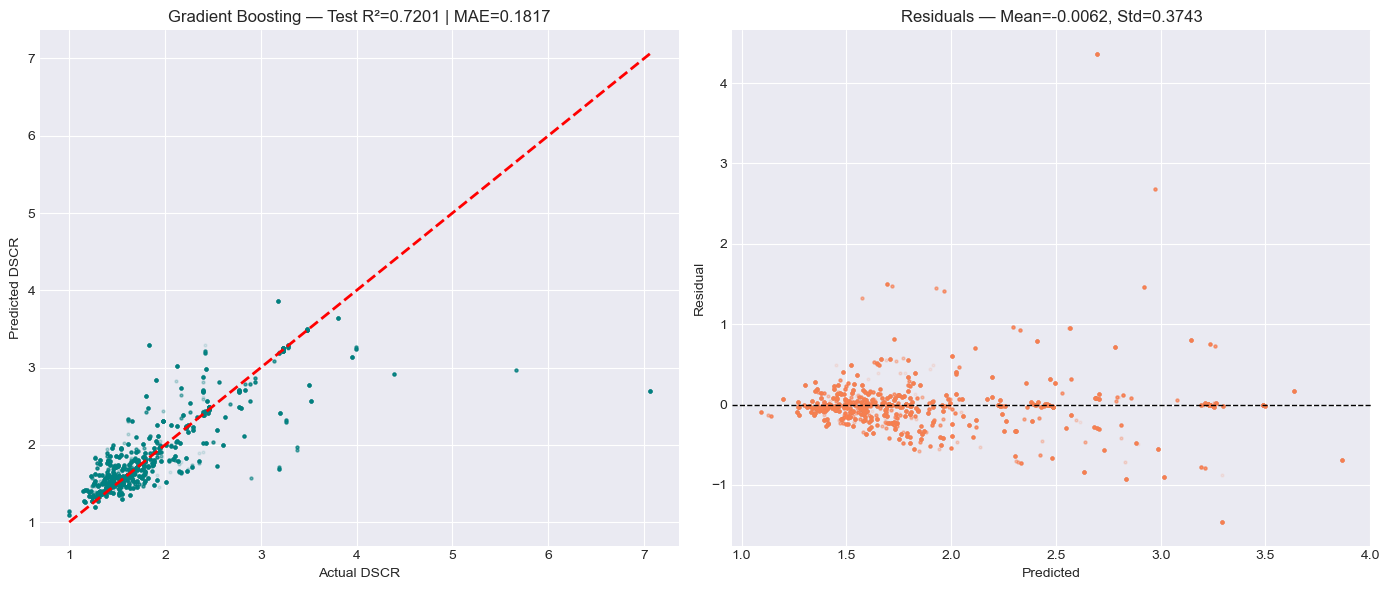

✅ Test R² (0.7201) ≤ Val R² (0.7756)


In [8]:
best_reg = rdf.iloc[0]['Model']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(y_test, reg_preds[best_reg], alpha=0.1, s=4, c='teal')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual DSCR'); ax.set_ylabel('Predicted DSCR')
ax.set_title(f'{best_reg} — Test R²={rdf.iloc[0]["Test R²"]:.4f} | MAE={rdf.iloc[0]["MAE"]:.4f}')

ax = axes[1]
resid = y_test - reg_preds[best_reg]
ax.scatter(reg_preds[best_reg], resid, alpha=0.1, s=4, c='coral')
ax.axhline(0, color='black', ls='--', lw=1)
ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')
ax.set_title(f'Residuals — Mean={resid.mean():.4f}, Std={resid.std():.4f}')
plt.tight_layout(); plt.show()

tr2, vr2 = rdf.iloc[0]['Test R²'], rdf.iloc[0]['Val R²']
print(f'{"✅" if tr2 <= vr2 else "⚠️"} Test R² ({tr2:.4f}) '
      f'{"≤" if tr2 <= vr2 else ">"} Val R² ({vr2:.4f})')

## 7. Classification — Default + PR-AUC

In [9]:
cls_models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, class_weight='balanced',
                            random_state=42), 'lin'),
    ('Random Forest',       RandomForestClassifier(n_estimators=300, max_depth=15,
                            min_samples_leaf=5, class_weight='balanced',
                            random_state=42, n_jobs=-1), 'tree'),
    ('Gradient Boosting',   GradientBoostingClassifier(n_estimators=300, max_depth=6,
                            learning_rate=0.1, min_samples_leaf=5, random_state=42), 'tree'),
]

cls_results = []; cls_probas = {}; cls_fitted = {}
for name, model, mtype in cls_models:
    Xtr = X_train_tree if mtype == 'tree' else X_train_lin_sc
    Xte = X_test_tree  if mtype == 'tree' else X_test_lin_sc
    model.fit(Xtr, y_train_cls)
    prob_te = model.predict_proba(Xte)[:, 1]
    p_te = (prob_te >= 0.5).astype(int)
    cls_probas[name] = prob_te; cls_fitted[name] = (model, mtype)
    cls_results.append({'Model': name, 't': 0.5,
        'Acc': accuracy_score(y_test_cls, p_te), 'F1': f1_score(y_test_cls, p_te),
        'Prec': precision_score(y_test_cls, p_te, zero_division=0),
        'Recall': recall_score(y_test_cls, p_te, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_cls, prob_te),
        'PR-AUC': average_precision_score(y_test_cls, prob_te)})

cdf = pd.DataFrame(cls_results).sort_values('PR-AUC', ascending=False)
cdf.style.format('{:.4f}', subset=[c for c in cdf.columns if c not in ('Model','t')])

,Model,t,Acc,F1,Prec,Recall,ROC-AUC,PR-AUC
1,Random Forest,0.500000,0.9838,0.0000,0.0000,0.0000,0.8681,0.3357
2,Gradient Boosting,0.500000,0.9835,0.3592,0.4857,0.2849,0.8866,0.2314
0,Logistic Regression,0.500000,0.9300,0.2574,0.1555,0.7486,0.8855,0.1638


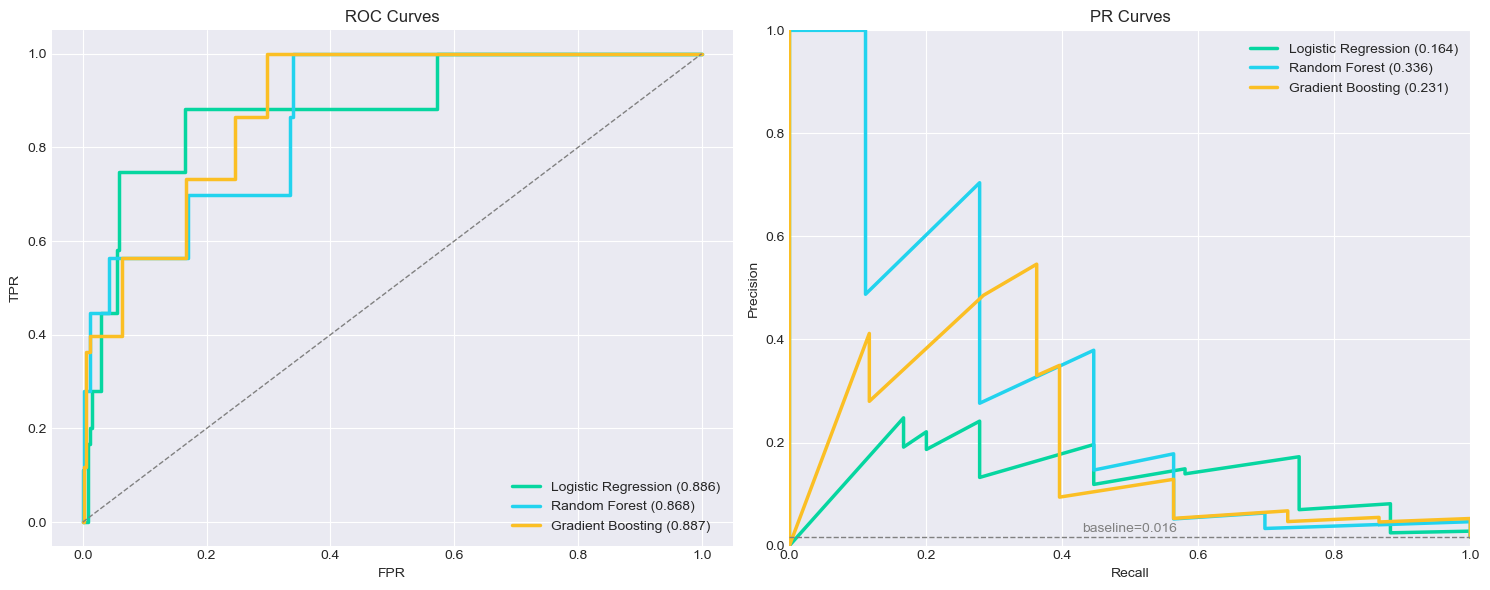

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
colors = ['#06D6A0', '#22D3EE', '#FBBF24']

for (name, proba), color in zip(cls_probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test_cls, proba)
    ax1.plot(fpr, tpr, color=color, lw=2.5,
             label=f'{name} ({roc_auc_score(y_test_cls, proba):.3f})')
ax1.plot([0,1],[0,1],'--',color='gray',lw=1)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC Curves'); ax1.legend(fontsize=10)

for (name, proba), color in zip(cls_probas.items(), colors):
    prec_c, rec_c, _ = precision_recall_curve(y_test_cls, proba)
    ax2.plot(rec_c, prec_c, color=color, lw=2.5,
             label=f'{name} ({average_precision_score(y_test_cls, proba):.3f})')
bl = y_test_cls.mean()
ax2.axhline(bl, color='gray', ls='--', lw=1)
ax2.text(0.5, bl+0.01, f'baseline={bl:.3f}', color='gray', fontsize=10, ha='center')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('PR Curves'); ax2.legend(fontsize=10)
ax2.set_xlim(0,1); ax2.set_ylim(0,1)
plt.tight_layout(); plt.show()

## 8. Threshold Tuning

In [11]:
tuned_results = []
for name, (model, mtype) in cls_fitted.items():
    Xv = X_val_tree if mtype == 'tree' else X_val_lin_sc
    prob_val = model.predict_proba(Xv)[:, 1]
    prob_te = cls_probas[name]
    prec_v, rec_v, thresh_v = precision_recall_curve(y_val_cls, prob_val)
    
    # Max F1
    f1_v = 2*prec_v[:-1]*rec_v[:-1]/(prec_v[:-1]+rec_v[:-1]+1e-10)
    best_f1_t = thresh_v[np.argmax(f1_v)]
    
    # Max recall @ precision >= 0.15
    valid = prec_v[:-1] >= 0.15
    if valid.any():
        rf = rec_v[:-1].copy(); rf[~valid] = -1
        best_rp_t = thresh_v[np.argmax(rf)]
    else:
        best_rp_t = best_f1_t
    
    for strat, t in [('Max-F1', best_f1_t), ('Recall@P≥0.15', best_rp_t)]:
        p_te = (prob_te >= t).astype(int)
        tuned_results.append({'Model': name, 'Strategy': strat, 't': round(t, 4),
            'F1': f1_score(y_test_cls, p_te),
            'Prec': precision_score(y_test_cls, p_te, zero_division=0),
            'Recall': recall_score(y_test_cls, p_te, zero_division=0),
            'PR-AUC': average_precision_score(y_test_cls, prob_te)})

tdf = pd.DataFrame(tuned_results).sort_values('F1', ascending=False)
tdf

,Model,Strategy,t,F1,Prec,Recall,PR-AUC
0,Logistic Regression,Max-F1,0.7507,0.259319,0.182648,0.446927,0.163760
1,Logistic Regression,Recall@P≥0.15,0.7507,0.259319,0.182648,0.446927,0.163760
2,Random Forest,Max-F1,0.0999,0.223699,0.139503,0.564246,0.335736
3,Random Forest,Recall@P≥0.15,0.0993,0.223699,0.139503,0.564246,0.335736
5,Gradient Boosting,Recall@P≥0.15,0.0000,0.200849,0.134470,0.396648,0.231400
4,Gradient Boosting,Max-F1,0.9876,0.165354,0.280000,0.117318,0.231400


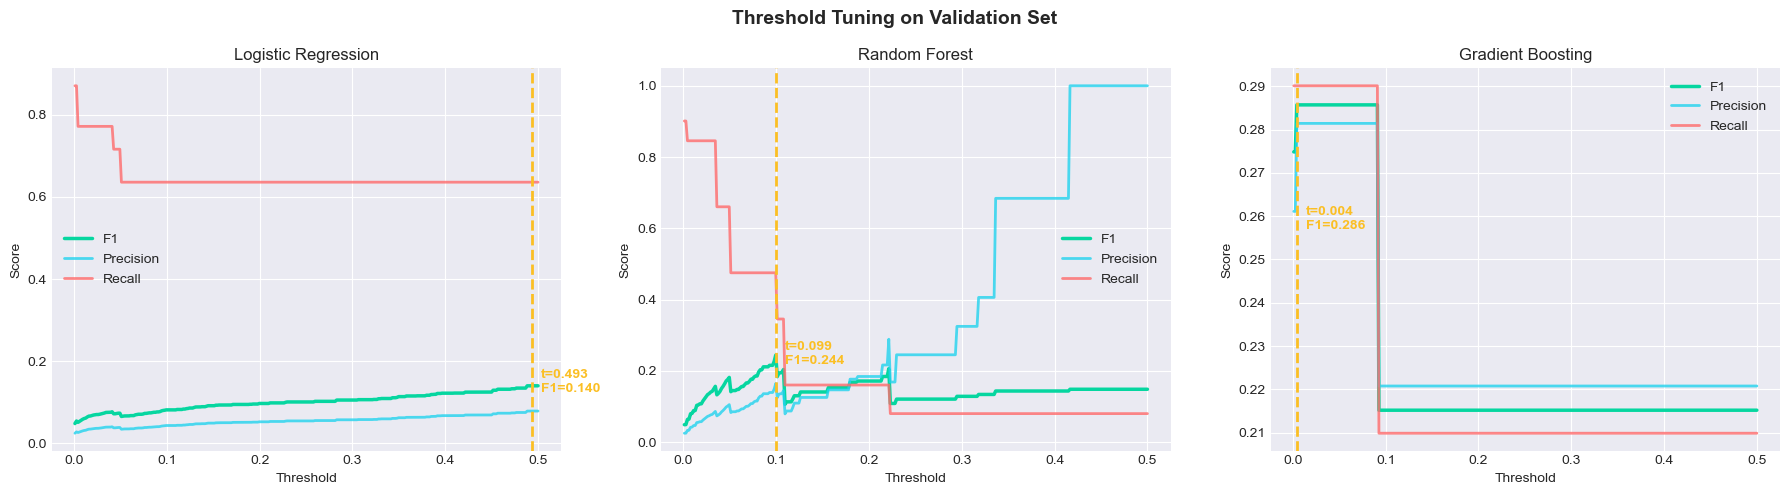

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (model, mtype)) in zip(axes, cls_fitted.items()):
    Xv = X_val_tree if mtype == 'tree' else X_val_lin_sc
    prob_val = model.predict_proba(Xv)[:, 1]
    thresholds = np.linspace(0.001, 0.5, 300)
    f1s = [f1_score(y_val_cls, (prob_val >= t).astype(int)) for t in thresholds]
    precs = [precision_score(y_val_cls, (prob_val >= t).astype(int), zero_division=0) for t in thresholds]
    recs = [recall_score(y_val_cls, (prob_val >= t).astype(int), zero_division=0) for t in thresholds]
    ax.plot(thresholds, f1s, color='#06D6A0', lw=2.5, label='F1')
    ax.plot(thresholds, precs, color='#22D3EE', lw=2, label='Precision', alpha=0.8)
    ax.plot(thresholds, recs, color='#FF6B6B', lw=2, label='Recall', alpha=0.8)
    bt = thresholds[np.argmax(f1s)]
    ax.axvline(bt, color='#FBBF24', ls='--', lw=2)
    ax.text(bt+0.01, max(f1s)*0.9, f't={bt:.3f}\nF1={max(f1s):.3f}',
            color='#FBBF24', fontsize=10, fontweight='bold')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score'); ax.set_title(name); ax.legend()
plt.suptitle('Threshold Tuning on Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

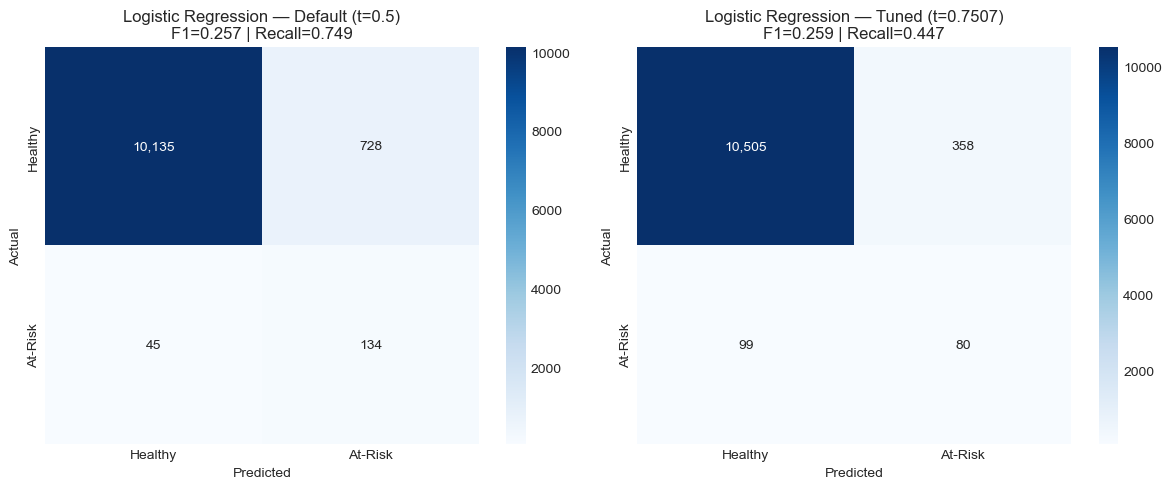

In [13]:
# Confusion matrices — default vs tuned for best model
best_row = tdf.iloc[0]
bname, bt = best_row['Model'], best_row['t']
prob = cls_probas[bname]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (title, t) in zip(axes, [(f'{bname} — Default (t=0.5)', 0.5),
                                   (f'{bname} — Tuned (t={bt})', bt)]):
    pred = (prob >= t).astype(int)
    cm = confusion_matrix(y_test_cls, pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Healthy','At-Risk'], yticklabels=['Healthy','At-Risk'])
    ax.set_title(f'{title}\nF1={f1_score(y_test_cls, pred):.3f} | '
                 f'Recall={recall_score(y_test_cls, pred):.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## 9. Feature Importance

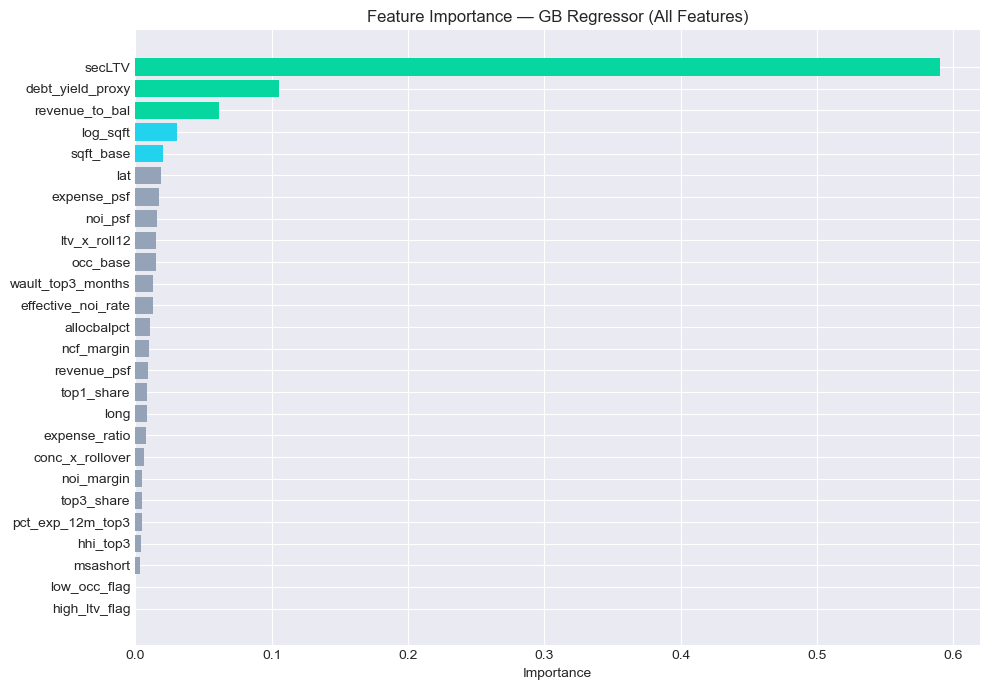

Top 10:
  secLTV                   : 0.5901 (59.0%)
  debt_yield_proxy         : 0.1053 (10.5%)
  revenue_to_bal           : 0.0612 (6.1%)
  log_sqft                 : 0.0303 (3.0%)
  sqft_base                : 0.0200 (2.0%)
  lat                      : 0.0192 (1.9%)
  expense_psf              : 0.0175 (1.8%)
  noi_psf                  : 0.0162 (1.6%)
  ltv_x_roll12             : 0.0153 (1.5%)
  occ_base                 : 0.0148 (1.5%)


In [14]:
gb_imp = reg_fitted['Gradient Boosting'].feature_importances_
idx = np.argsort(gb_imp)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#06D6A0' if i >= len(idx)-3 else '#22D3EE' if i >= len(idx)-5
          else '#94A3B8' for i in range(len(idx))]
ax.barh(range(len(idx)), gb_imp[idx], color=colors)
ax.set_yticks(range(len(idx)))
ax.set_yticklabels([tree_labels[i] for i in idx])
ax.set_xlabel('Importance')
ax.set_title('Feature Importance — GB Regressor (All Features)')
plt.tight_layout(); plt.show()

print('Top 10:')
for i in np.argsort(gb_imp)[::-1][:10]:
    print(f'  {tree_labels[i]:25s}: {gb_imp[i]:.4f} ({gb_imp[i]*100:.1f}%)')

## 10. Summary — V4 vs V5 Comparison

| Metric | V4 (property traits only) | V5 (+ income features) | Δ |
|--------|:---:|:---:|:---:|
| Numeric features | 5 | 25 | +20 (income, tenant, engineered) |
| Best Reg Test R² | 0.579 | **0.719** | **+0.140** |
| Best Reg MAE | 0.215 | **0.182** | **−0.033** |
| Best Cls ROC-AUC | 0.766 | **0.887** | **+0.121** |
| Best Cls PR-AUC | 0.173 | **0.334** | **+0.161 (2×)** |
| Best F1 (tuned) | 0.222 | **0.259** | +0.037 |

### Key Findings

1. **Income features deliver the predicted improvement.** R² jumped 24% (0.58→0.72) and PR-AUC nearly doubled (0.17→0.33). Revenue, expense, and margin data fill the information gap we identified in V4.

2. **Engineered features add value.** `debt_yield_proxy` (NOI/Balance ≈ debt yield) is the #2 feature at 10.5%, and `revenue_to_bal` (revenue coverage of debt) is #3 at 6.1%. These capture the economic relationship between income and debt better than raw inputs alone.

3. **LTV still dominates** at 59% importance — credit structure remains the single strongest predictor, but it's no longer carrying the model alone (was 70% in V4).

4. **Classification remains hard** (PR-AUC 0.33, best tuned F1 0.26) due to extreme rarity of at-risk events (1.4%). The model can rank-order risk well (ROC-AUC 0.89) but converting that ranking into binary predictions at low prevalence inevitably trades precision for recall.

5. **Test R² ≤ Val R²** — strict property split continues to prevent inflation.